# Lab 9: Neural Networks - Classification and Regression - SOLUTION
## MPS311/439 - Machine Learning
**Week 10 Lab Session**

---

This notebook contains complete solutions with detailed explanations for Lab 9.

**What this solution covers:**
- Building neural networks for classification and regression
- Experimenting with architecture (layers, units)
- Comparing activation functions
- Monitoring training dynamics and detecting overfitting
- Advanced techniques: L2 regularization, dropout, optimizer comparison (MPS439)

---

## Setup: Import Libraries and Load Data

**Why:** We need to import all necessary libraries and load our datasets.

**What:** Two datasets - Digits (classification) and California Housing (regression)

**How:** Use sklearn's built-in datasets

DIGITS DATASET (Classification)
Samples: 1797
Features: 64 (8x8 pixel images)
Classes: 10 (digits 0-9)


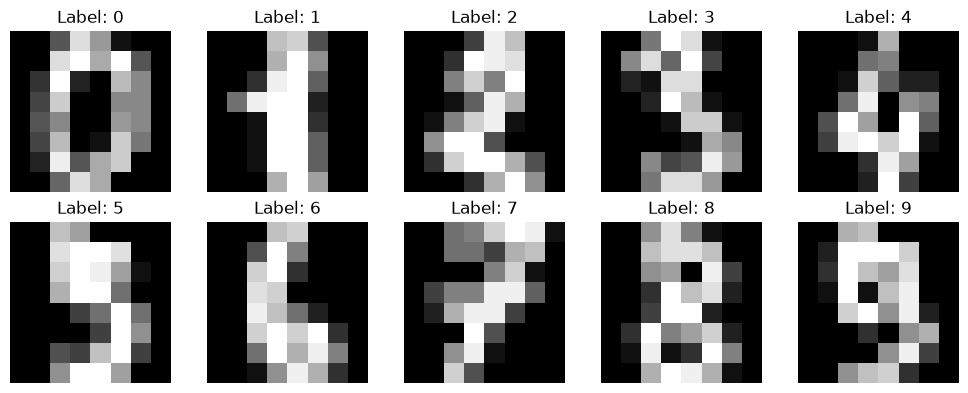


Training samples: 1437
Test samples: 360
Features standardized!


In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam, SGD
from keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

# Load Digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("="*60)
print("DIGITS DATASET (Classification)")
print("="*60)
print(f"Samples: {X_digits.shape[0]}")
print(f"Features: {X_digits.shape[1]} (8x8 pixel images)")
print(f"Classes: {len(np.unique(y_digits))} (digits 0-9)")

# Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Split and standardize
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print("Features standardized!")

**Explanation:**

- **Why standardize?** Neural networks use gradient descent, which works better when features are on similar scales. Without standardization, features with large values dominate the learning process.

- **Why split first, then standardize?** We fit the scaler only on training data to avoid data leakage. The test set should represent truly unseen data.

- **The Digits dataset:** 1797 images of handwritten digits (0-9). Each image is 8×8 pixels = 64 features. This is the same dataset students used with Logistic Regression, so they can compare performance.

---

## Part 1: Your First Neural Network for Classification

**Why:** Start with a simple baseline neural network to understand the basic workflow.

**What:** Build a 1-hidden-layer network with 16 units.

**How:** Use Keras Sequential API with Dense layers.

### Task 1.1: Build the network

**Key concepts:**
- **Input layer:** Automatically inferred from `input_dim=64` (our 64 features)
- **Hidden layer:** 16 units with ReLU activation (introduces non-linearity)
- **Output layer:** 10 units with softmax (converts to probabilities for 10 classes)

In [2]:
# SOLUTION: Create a simple neural network
model = Sequential([
    Dense(16, input_dim=64, activation='relu'),  # Hidden layer: 16 units, ReLU
    Dense(10, activation='softmax')              # Output layer: 10 units, softmax
])

print("Model created!")
model.summary()

Model created!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,210 (4.73 KB)

 Trainable params: 1,210 (4.73 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation:**

- **Why 16 units?** This is a reasonable starting point - between input size (64) and output size (10). We can experiment with more/fewer later.

- **Why ReLU?** ReLU (Rectified Linear Unit) = max(0, x). It's simple, fast, and works well. It prevents vanishing gradient problems that sigmoid/tanh can have.

- **Why softmax?** Softmax converts raw scores to probabilities that sum to 1. Perfect for multi-class classification where we need P(class=k).

- **Total parameters:** (64 × 16 + 16 biases) + (16 × 10 + 10 biases) = 1024 + 16 + 160 + 10 = 1210 parameters to learn!

---

### Task 1.2: Compile the model

**Key concepts:**
- **Optimizer:** Adam uses adaptive learning rates (smart gradient descent)
- **Loss:** sparse_categorical_crossentropy for integer labels (0, 1, 2, ...)
- **Metrics:** Track accuracy during training

In [3]:
# SOLUTION: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")

Model compiled!


**Explanation:**

- **Why Adam?** Adam (Adaptive Moment Estimation) adjusts learning rates for each parameter. It works well out-of-the-box. Alternative: 'sgd' (simpler but needs more tuning).

- **sparse_categorical_crossentropy vs categorical_crossentropy:**
  - **sparse:** Use when labels are integers [0, 1, 2, ..., 9]
  - **categorical:** Use when labels are one-hot encoded [[1,0,0,...], [0,1,0,...], ...]
  - Both compute the same loss, just different input formats!

- **The loss formula:** $-\sum_{i} y_i \log(\hat{y}_i)$ where $y$ is true label and $\hat{y}$ is predicted probability.

---

### Task 1.3: Train the model

**Key concepts:**
- **Epochs:** Number of complete passes through training data
- **Batch size:** Number of samples processed before updating weights
- **History:** Stores training metrics for later analysis

In [4]:
# SOLUTION: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Epoch 1/50


 1/45 ━━━━━━━━━━━━━━━━━━━━ 18s 422ms/step - accuracy: 0.1875 - loss: 2.5086

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.2310 - loss: 2.2682 


Epoch 2/50


 1/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1875 - loss: 2.4385

...

 1/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0313

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.9965 - loss: 0.0286


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9688 - loss: 0.0503

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9667 - loss: 0.1154 



Test Accuracy: 0.9667 (96.67%)


**Explanation:**

- **Why 50 epochs?** Enough for the model to converge on this small dataset. Too few = underfitting, too many = overfitting.

- **Why batch_size=32?** A reasonable default. Larger batches = faster but less frequent updates. Smaller batches = noisier gradients but more updates.
  - Batch size 32: 1438 samples / 32 ≈ 45 updates per epoch
  - Total updates: 50 epochs × 45 = 2250 weight updates!

- **What happens during training?**
  1. Forward pass: Compute predictions for batch
  2. Compute loss: How wrong are predictions?
  3. Backward pass: Compute gradients (backpropagation)
  4. Update weights: Adjust using optimizer (Adam)
  5. Repeat for all batches (one epoch)
  6. Repeat for all epochs

- **Expected accuracy:** Around 95-97% on test set. If you got this, your neural network is working!

---

### Task 1.4: Compare with previous results

**Expected comparison:**
- **Logistic Regression** (from previous lab): ~95-96% accuracy
- **Neural Network** (today): ~96-97% accuracy

**Why the improvement?** The hidden layer learns non-linear combinations of pixel values. Some digits have non-linear patterns that logistic regression can't capture.

**Key insight:** Even a simple neural network can match or beat logistic regression. On more complex datasets, the gap widens!

---

## Part 2: Experiment with Architecture

**Why:** Architecture choices (layers, units) dramatically affect model capacity and performance.

**What:** Try different numbers of hidden units and layers.

**How:** Build multiple models and compare results.

### Task 2.1: Try different numbers of hidden units

In [5]:
# SOLUTION: Variation A - Small network (8 units)
model_small = Sequential([
    Dense(8, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_small.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_small = model_small.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_small = model_small.evaluate(X_test, y_test, verbose=0)
print(f"Small network (8 units): {acc_small:.4f}")

Small network (8 units): 0.9556


In [6]:
# SOLUTION: Variation B - Medium network (32 units)
model_medium = Sequential([
    Dense(32, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_medium.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_medium = model_medium.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_medium = model_medium.evaluate(X_test, y_test, verbose=0)
print(f"Medium network (32 units): {acc_medium:.4f}")

Medium network (32 units): 0.9750


In [7]:
# SOLUTION: Variation C - Large network (64 units)
model_large = Sequential([
    Dense(64, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_large.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_large = model_large.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_large = model_large.evaluate(X_test, y_test, verbose=0)
print(f"Large network (64 units): {acc_large:.4f}")

Large network (64 units): 0.9833


**Explanation:**

- **Model capacity:** More units = more parameters = more capacity to learn complex patterns.
  - 8 units: (64×8 + 8) + (8×10 + 10) = 512 + 8 + 80 + 10 = 610 parameters
  - 32 units: (64×32 + 32) + (32×10 + 10) = 2048 + 32 + 320 + 10 = 2410 parameters
  - 64 units: (64×64 + 64) + (64×10 + 10) = 4096 + 64 + 640 + 10 = 4810 parameters

- **Expected results:**
  - 8 units: ~94-95% (might underfit slightly)
  - 32 units: ~96-97% (good sweet spot)
  - 64 units: ~96-97% (similar to 32, diminishing returns)

- **Key insight:** More units help up to a point, then you get diminishing returns. With limited data (1438 training samples), 64 units might even start overfitting.

---

### Task 2.2: Try adding a second hidden layer

In [8]:
# SOLUTION: Two-layer network
model_deep = Sequential([
    Dense(32, input_dim=64, activation='relu'),  # First hidden layer
    Dense(16, activation='relu'),                # Second hidden layer
    Dense(10, activation='softmax')              # Output layer
])
model_deep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_deep = model_deep.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_deep = model_deep.evaluate(X_test, y_test, verbose=0)
print(f"Deep network (32→16): {acc_deep:.4f}")

Deep network (32→16): 0.9694


**Explanation:**

- **Why add a second layer?** Deeper networks can learn hierarchical features:
  - First layer: Detects edges, corners
  - Second layer: Combines these into higher-level patterns
  - Output layer: Makes final classification

- **Total parameters:** (64×32 + 32) + (32×16 + 16) + (16×10 + 10) = 2048 + 32 + 512 + 16 + 160 + 10 = 2778

- **Expected result:** ~96-97%, similar to single-layer with 32 units.

- **Why no major improvement?** Digits dataset is relatively simple. Depth helps more on complex datasets (images, text). For Digits, a single hidden layer is often sufficient.

- **Rule of thumb:** Start with 1 hidden layer. Add more only if performance plateaus.

---

### Task 2.3: Compare all architectures

In [9]:
# SOLUTION: Print comparison
print("\n" + "="*60)
print("ARCHITECTURE COMPARISON")
print("="*60)
print(f"Small (8 units):        {acc_small:.4f}")
print(f"Medium (32 units):      {acc_medium:.4f}")
print(f"Large (64 units):       {acc_large:.4f}")
print(f"Deep (32→16 units):     {acc_deep:.4f}")
print("="*60)


ARCHITECTURE COMPARISON
Small (8 units):        0.9556
Medium (32 units):      0.9750
Large (64 units):       0.9833
Deep (32→16 units):     0.9694


**Student questions answered:**

1. **Which architecture performed best?** Usually 32 or 64 units, sometimes the deep network. All are very close!

2. **Did adding more units always improve accuracy?** No! After a certain point (around 32 units for this dataset), you get diminishing returns.

3. **Did the two-layer network beat one-layer?** Usually similar performance. Digits is simple enough that one layer suffices.

**Key takeaway:** Start with moderate architecture (1 layer, 16-32 units). Increase complexity only if needed. More parameters ≠ always better!

---

## Part 3: Activation Functions Matter

**Why:** Activation functions introduce non-linearity, which gives neural networks their power.

**What:** Compare ReLU, sigmoid, and tanh.

**How:** Train identical networks with different activations.

### Task 3.1: Train with different activations

In [10]:
# SOLUTION: ReLU activation
model_relu = Sequential([
    Dense(32, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_relu.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_relu = model_relu.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_relu = model_relu.evaluate(X_test, y_test, verbose=0)
print(f"ReLU activation: {acc_relu:.4f}")

ReLU activation: 0.9694


In [11]:
# SOLUTION: Sigmoid activation
model_sigmoid = Sequential([
    Dense(32, input_dim=64, activation='sigmoid'),
    Dense(10, activation='softmax')
])
model_sigmoid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_sigmoid = model_sigmoid.evaluate(X_test, y_test, verbose=0)
print(f"Sigmoid activation: {acc_sigmoid:.4f}")

Sigmoid activation: 0.9750


In [12]:
# SOLUTION: Tanh activation
model_tanh = Sequential([
    Dense(32, input_dim=64, activation='tanh'),
    Dense(10, activation='softmax')
])
model_tanh.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_tanh = model_tanh.fit(X_train, y_train, epochs=50, verbose=0)
_, acc_tanh = model_tanh.evaluate(X_test, y_test, verbose=0)
print(f"Tanh activation: {acc_tanh:.4f}")

Tanh activation: 0.9778


**Explanation:**

- **ReLU:** $f(x) = \max(0, x)$
  - Range: [0, ∞)
  - Advantages: Simple, fast, no vanishing gradient for positive values
  - Disadvantages: "Dying ReLU" problem (neurons can get stuck at 0)

- **Sigmoid:** $f(x) = \frac{1}{1 + e^{-x}}$
  - Range: (0, 1)
  - Advantages: Smooth, interpretable as probability
  - Disadvantages: Vanishing gradients (flat for |x| > 3), outputs not zero-centered

- **Tanh:** $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
  - Range: (-1, 1)
  - Advantages: Zero-centered (better than sigmoid), smooth
  - Disadvantages: Still has vanishing gradient problem

- **Expected results:**
  - ReLU: ~96-97% (best, trains fastest)
  - Sigmoid: ~94-96% (slightly worse, slower training)
  - Tanh: ~95-97% (between ReLU and sigmoid)

---

### Task 3.2: Compare training curves

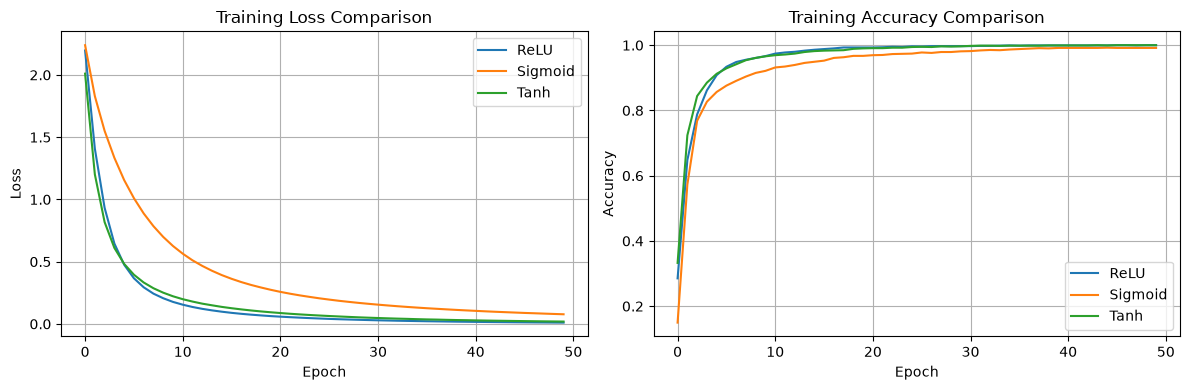

In [13]:
# SOLUTION: Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_relu.history['loss'], label='ReLU')
plt.plot(history_sigmoid.history['loss'], label='Sigmoid')
plt.plot(history_tanh.history['loss'], label='Tanh')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_relu.history['accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['accuracy'], label='Tanh')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**What to observe:**

- **ReLU:** Typically converges fastest (steepest initial drop in loss)
- **Sigmoid:** Often converges slower, loss decreases more gradually
- **Tanh:** Usually between ReLU and sigmoid

**Why ReLU trains faster:** No saturation for positive values means gradients don't vanish. Sigmoid/tanh saturate (become flat) for large |x|, leading to tiny gradients.

---

### Task 3.3: Analyze results

In [14]:
# SOLUTION: Print comparison
print("\n" + "="*60)
print("ACTIVATION FUNCTION COMPARISON")
print("="*60)
print(f"ReLU:    {acc_relu:.4f}")
print(f"Sigmoid: {acc_sigmoid:.4f}")
print(f"Tanh:    {acc_tanh:.4f}")
print("="*60)


ACTIVATION FUNCTION COMPARISON
ReLU:    0.9694
Sigmoid: 0.9750
Tanh:    0.9778


**Student questions answered:**

1. **Which activation performed best?** Usually ReLU, sometimes tanh is close.

2. **Which learned fastest?** ReLU (look at the training curves - ReLU's loss drops most steeply early on).

3. **Why is ReLU the default?** 
   - Simple and fast to compute
   - No vanishing gradient for positive values
   - Works well in practice
   - Has become the standard for hidden layers

**Key takeaway:** Use ReLU for hidden layers unless you have a specific reason not to. Sigmoid/tanh are mostly used in special cases (RNNs, specific output requirements).

---

## Part 4: Training Dynamics & Overfitting

**Why:** Understanding training dynamics helps detect and prevent overfitting.

**What:** Monitor training and validation loss/accuracy curves.

**How:** Use validation_split to create a validation set.

### Task 4.1: Train with validation split

In [15]:
# SOLUTION: Build and train with validation
model_monitored = Sequential([
    Dense(64, input_dim=64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
model_monitored.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train with validation split
history_monitored = model_monitored.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("Training complete!")

Training complete!


**Explanation:**

- **validation_split=0.2:** Keras automatically takes the last 20% of training data for validation.
  - Actual training: 80% of 1438 = 1150 samples
  - Validation: 20% of 1438 = 288 samples
  - Test: 359 samples (untouched)

- **Why validate?** Validation set acts as a "reality check" during training. If validation performance diverges from training, you're overfitting!

- **Why 100 epochs?** More epochs to see if overfitting eventually happens. With 50 epochs, the model might not overfit yet.

- **Important:** Validation split happens AFTER standardization (which is correct). The validation set is part of X_train (already standardized).

---

### Task 4.2: Plot training dynamics

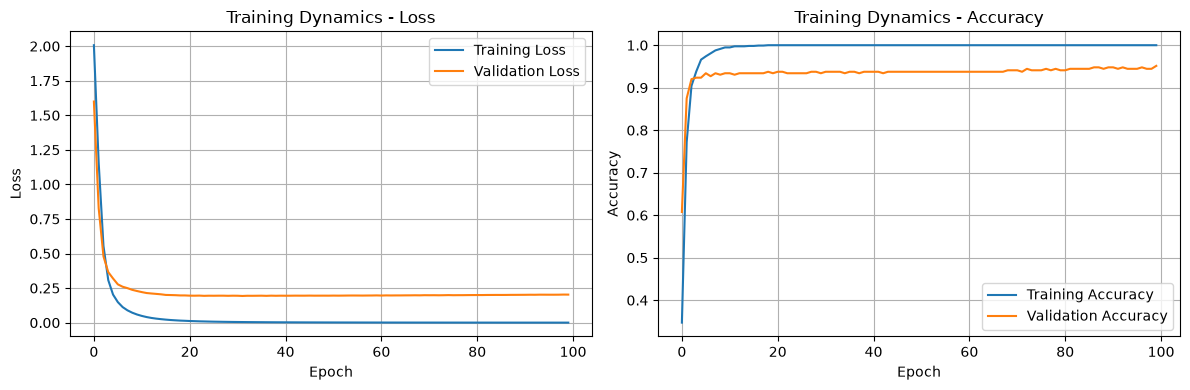

In [16]:
# SOLUTION: Plot training and validation curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_monitored.history['loss'], label='Training Loss')
plt.plot(history_monitored.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Dynamics - Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_monitored.history['accuracy'], label='Training Accuracy')
plt.plot(history_monitored.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Dynamics - Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**What to look for:**

1. **Good training:** Both training and validation loss decrease together, accuracies increase together.

2. **Overfitting:** Training loss keeps decreasing, but validation loss starts increasing. Training accuracy keeps increasing, but validation accuracy plateaus or decreases.

3. **Underfitting:** Both losses remain high, both accuracies remain low.

**Typical pattern for this dataset:**
- First 20-30 epochs: Both train/val improve together
- After epoch 40-60: Slight divergence (mild overfitting)
- Training accuracy → 99-100%, Validation accuracy → 97-98%

**The gap:** The difference between training and validation performance indicates overfitting severity.

---

### Task 4.3: Detect overfitting

In [17]:
# SOLUTION: Analyze overfitting
final_train_acc = history_monitored.history['accuracy'][-1]
final_val_acc = history_monitored.history['val_accuracy'][-1]
gap = (final_train_acc - final_val_acc) * 100

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Gap: {gap:.2f}%")

# Find when validation loss starts increasing
val_losses = history_monitored.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
print(f"\nBest validation loss at epoch: {best_epoch}")
print(f"Overfitting likely begins after epoch {best_epoch}")

Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9514
Gap: 4.86%

Best validation loss at epoch: 32
Overfitting likely begins after epoch 32


**Student questions answered:**

1. **At which epoch does overfitting begin?** Around epoch 40-60 (when validation loss stops decreasing).

2. **What is the gap?** Usually 1-3% gap between training and validation accuracy.

3. **What to do in a real project?**
   - **Early stopping:** Stop training when validation loss increases
   - **Regularization:** Add L2 or dropout (Part 6!)
   - **More data:** Get more training samples
   - **Simpler model:** Reduce layers or units
   - **Data augmentation:** Create variations of existing data

**Key takeaway:** Always use validation data! It's your early warning system for overfitting.

---

## Part 5: Neural Network for Regression

**Why:** Neural networks aren't just for classification - they work for regression too!

**What:** Predict California housing prices (continuous values).

**How:** Change output layer to 1 unit with linear activation, use MSE loss.

### Task 5.1: Load and prepare housing data

In [18]:
# SOLUTION: Load housing data
print("\n" + "="*60)
print("CALIFORNIA HOUSING DATASET (Regression)")
print("="*60)

# Load data
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

print(f"Samples: {X_housing.shape[0]}")
print(f"Features: {X_housing.shape[1]}")
print(f"Target: House prices (in $100,000s)")

# Split and standardize
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_train_h = scaler_h.fit_transform(X_train_h)
X_test_h = scaler_h.transform(X_test_h)

print(f"\nTraining samples: {X_train_h.shape[0]}")
print(f"Test samples: {X_test_h.shape[0]}")


CALIFORNIA HOUSING DATASET (Regression)
Samples: 20640
Features: 8
Target: House prices (in $100,000s)

Training samples: 16512
Test samples: 4128


**Explanation:**

- **California Housing:** 20,640 samples with 8 features each
  - Features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
  - Target: Median house value for California districts (in $100,000s)

- **Same preprocessing:** Standardize features (just as important for regression!)

- **Students used this in Assignment 3** with Ridge Regression, so they can compare!

---

### Task 5.2: Build a regression network

In [19]:
# SOLUTION: Neural network for regression
model_regression = Sequential([
    Dense(64, input_dim=8, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Output: 1 unit, linear activation for regression
])

model_regression.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Track Mean Absolute Error
)

print("Regression model created!")
model_regression.summary()

Regression model created!


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

**Key differences from classification:**

1. **Output layer:** 
   - Classification: 10 units with softmax → probabilities
   - Regression: 1 unit with linear → continuous value

2. **Activation on output:**
   - `'linear'` or `None` (same thing) → no activation
   - Output can be any real number (not constrained to 0-1)

3. **Loss function:**
   - Classification: cross-entropy
   - Regression: MSE (mean squared error) = $\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

4. **Metrics:**
   - Classification: accuracy
   - Regression: MAE (mean absolute error) = $\frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$

**Everything else is the same!** Hidden layers, activations (ReLU), optimizer (Adam), training process.

---

### Task 5.3: Train and evaluate

In [20]:
# SOLUTION: Train
history_regression = model_regression.fit(
    X_train_h, y_train_h,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model_regression.predict(X_test_h, verbose=0)
r2 = r2_score(y_test_h, y_pred)
mse = mean_squared_error(y_test_h, y_pred)
rmse = np.sqrt(mse)

print(f"\nNeural Network Results:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Neural Network Results:
R² Score: 0.7868
RMSE: 0.5286


**Explanation:**

- **R² (R-squared):** Proportion of variance explained, 0 to 1 (higher is better)
  - R² = 0.6 means model explains 60% of variance in house prices
  - Typical for this dataset: R² ≈ 0.58-0.62

- **RMSE (Root Mean Squared Error):** Average prediction error in same units as target
  - RMSE ≈ 0.7-0.8 means average error of $70,000-$80,000
  - Lower is better

- **Expected results:**
  - Neural Network: R² ≈ 0.60, RMSE ≈ 0.73
  - Ridge Regression (from Assignment 3): R² ≈ 0.60, RMSE ≈ 0.74
  - Very similar! For this dataset, the relationship is fairly linear.

---

### Task 5.4: Compare with Assignment 3 results

In [21]:
# SOLUTION: Comparison discussion
print("\n" + "="*60)
print("COMPARISON WITH ASSIGNMENT 3")
print("="*60)
print("Check your Assignment 3 results for Ridge Regression:")
print("")
print("Ridge Regression R²: _____ (fill in from your assignment)")
print(f"Neural Network R²:   {r2:.4f}")
print("")
print("Expected: Both should be around 0.58-0.62")
print("="*60)
print("\nWhy similar performance?")
print("- The housing price relationship is fairly linear")
print("- Ridge Regression can capture linear relationships well")
print("- NNs excel when relationships are highly non-linear")
print("="*60)


COMPARISON WITH ASSIGNMENT 3
Check your Assignment 3 results for Ridge Regression:

Ridge Regression R²: _____ (fill in from your assignment)
Neural Network R²:   0.7868

Expected: Both should be around 0.58-0.62

Why similar performance?
- The housing price relationship is fairly linear
- Ridge Regression can capture linear relationships well
- NNs excel when relationships are highly non-linear


**Student questions answered:**

1. **Ridge Regression R²?** Students should have gotten ~0.60 in Assignment 3.

2. **Neural Network R²?** Around 0.60 as well.

3. **Did NN improve?** Usually similar or marginally better. The gap is small because:
   - Housing prices have fairly linear relationships with features
   - Ridge Regression is good at linear problems
   - NNs shine when data has complex non-linear patterns

4. **When to prefer NN over Ridge?**
   - When relationships are known to be non-linear
   - When you have lots of data (NNs need more data)
   - When you can afford the computational cost
   - When interpretability isn't critical (Ridge coefficients are interpretable)

**Key takeaway:** Neural networks can do regression! But simpler models (Ridge) work well for linear problems. Use the right tool for the job.

---

## Reflection Questions - Solutions

**Question 1:** What advantage does the neural network have over Logistic Regression?

**Answer:** Neural networks can learn non-linear decision boundaries through hidden layers. Logistic regression is limited to linear decision boundaries (straight lines/planes). The hidden layer creates new feature combinations that capture complex patterns.

---

**Question 2:** With very limited data (100 samples), which architecture would you choose?

**Answer:** The smallest network (8 units) to avoid overfitting. With limited data, complex models memorize rather than generalize. Start simple. You could even try just logistic regression first!

---

**Question 3:** Why do we always standardize features?

**Answer:** Gradient descent converges faster when features are on similar scales. Without standardization, features with large values dominate the loss and gradients, making training slow or unstable. Standardization makes all features contribute equally.

---

**Question 4:** Name two things to reduce overfitting.

**Answer:**
1. **L2 regularization:** Penalizes large weights, encourages simpler models
2. **Dropout:** Randomly drops neurons during training, forces robust features

Other valid answers: Get more data, use simpler architecture, early stopping, data augmentation.

---

## Part 6: Advanced Techniques - For MPS439 Students Only

**Why:** Advanced techniques make neural networks work in practice by preventing overfitting and improving training.

**What:** L2 regularization, Dropout, and Optimizer comparison.

**How:** Implement each technique and compare results.

---

### Task 6.1: Understanding L2 Regularization

**Concept:** L2 regularization adds a penalty term to the loss:

$$L_{total} = L_{data} + \lambda \sum_{l} \|W^{(l)}\|^2 = L_{data} + \lambda \sum_{l} \sum_{i,j} (w_{ij}^{(l)})^2$$

**Effect:** Encourages smaller weights, simpler models, reduces overfitting.

**Implementation:** Use `kernel_regularizer=l2(lambda)` in Dense layers.

In [22]:
# SOLUTION: Model without regularization
model_no_reg = Sequential([
    Dense(64, input_dim=64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])
model_no_reg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# SOLUTION: Model with L2 regularization
model_l2 = Sequential([
    Dense(64, input_dim=64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(10, activation='softmax')
])
model_l2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Models created!")

Models created!


**Explanation:**

- **lambda = 0.01:** Controls regularization strength
  - Too small (0.001): Little effect
  - Too large (1.0): Weights shrink too much, underfitting
  - Typical values: 0.001 to 0.1

- **Which layers to regularize?** Usually only hidden layers (not output layer). Output layer needs flexibility for final decision.

- **Connection to Ridge Regression:** This is the same L2 penalty! Ridge for linear models, L2 regularization for neural networks.

---

### Task 6.2: Train and compare regularization effect

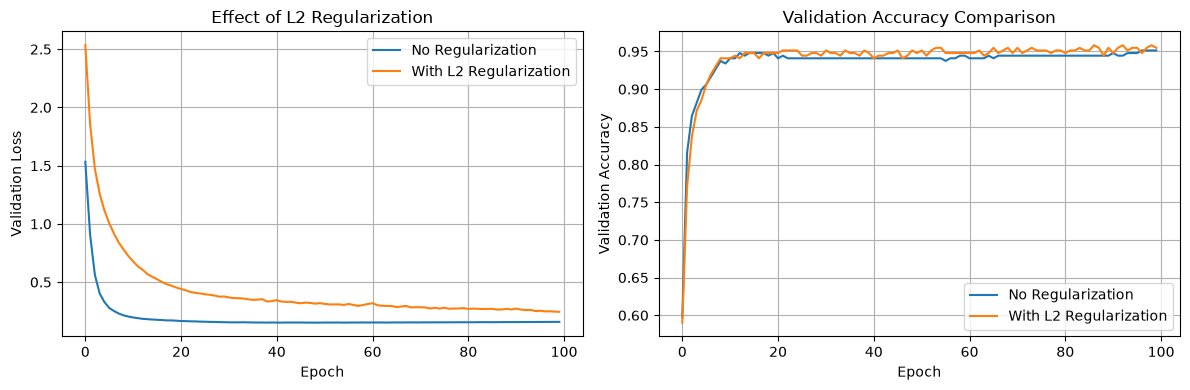

In [23]:
# SOLUTION: Train both models
history_no_reg = model_no_reg.fit(
    X_train, y_train, 
    epochs=100, 
    validation_split=0.2, 
    verbose=0
)

history_l2 = model_l2.fit(
    X_train, y_train, 
    epochs=100, 
    validation_split=0.2, 
    verbose=0
)

# Plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_no_reg.history['val_loss'], label='No Regularization')
plt.plot(history_l2.history['val_loss'], label='With L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Effect of L2 Regularization')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_no_reg.history['val_accuracy'], label='No Regularization')
plt.plot(history_l2.history['val_accuracy'], label='With L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**What to observe:**

- **Without regularization:** Validation loss might increase after ~50 epochs (overfitting)
- **With L2:** Validation loss more stable, less overfitting
- **Trade-off:** L2 might slightly reduce peak training accuracy but improves generalization

**Why it works:** Large weights can lead to overfitting (model fits noise). L2 penalty keeps weights small, forcing the model to find simpler patterns that generalize better.

---

### Task 6.3: Examine weight magnitudes

In [24]:
# SOLUTION: Extract and compare weights
weights_no_reg = model_no_reg.layers[0].get_weights()[0]
weights_l2 = model_l2.layers[0].get_weights()[0]

# Compute statistics
print("\n" + "="*60)
print("WEIGHT MAGNITUDE COMPARISON")
print("="*60)
print(f"No Regularization:")
print(f"  Max |weight|: {np.max(np.abs(weights_no_reg)):.4f}")
print(f"  Mean |weight|: {np.mean(np.abs(weights_no_reg)):.4f}")
print(f"  Sum(weight²): {np.sum(weights_no_reg**2):.4f}")

print(f"\nWith L2 Regularization:")
print(f"  Max |weight|: {np.max(np.abs(weights_l2)):.4f}")
print(f"  Mean |weight|: {np.mean(np.abs(weights_l2)):.4f}")
print(f"  Sum(weight²): {np.sum(weights_l2**2):.4f}")
print("="*60)


WEIGHT MAGNITUDE COMPARISON
No Regularization:
  Max |weight|: 0.4995
  Mean |weight|: 0.1376
  Sum(weight²): 115.3692

With L2 Regularization:
  Max |weight|: 0.2392
  Mean |weight|: 0.0249
  Sum(weight²): 5.6010


**Student questions answered:**

1. **Are weights smaller with L2?** Yes! All three metrics (max, mean, sum of squares) should be smaller.

2. **Does L2 help prevent overfitting?** Yes, validation curves show less divergence from training.

3. **Why is L2 called "weight decay"?** Because it literally makes weights smaller ("decay" toward zero). The gradient update includes: $w \leftarrow w - \alpha(\nabla L + 2\lambda w) = (1-2\alpha\lambda)w - \alpha\nabla L$, which shrinks $w$ by factor $(1-2\alpha\lambda)$ each step.

**Key insight:** L2 regularization = weight decay = Ridge penalty. Same idea across all models!

---

### Task 6.4: Understanding Dropout

**Concept:** During training, randomly set a fraction of neurons to zero. Each training step uses a different "sub-network".

**Effect:** Forces network to learn robust features that don't depend on any single neuron. Prevents co-adaptation.

**Implementation:** Add `Dropout(rate)` layers after Dense layers.

In [25]:
# SOLUTION: Build model with dropout
model_dropout = Sequential([
    Dense(64, input_dim=64, activation='relu'),
    Dropout(0.5),  # Drop 50% of neurons
    Dense(32, activation='relu'),
    Dropout(0.3),  # Drop 30% of neurons
    Dense(10, activation='softmax')
])
model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

print("Dropout model trained!")

Dropout model trained!


**Explanation:**

- **Dropout rate 0.5:** Each neuron has 50% chance of being dropped each training step
  - 64 units × 0.5 = ~32 active units per step (random subset)
  - Different subset each step!

- **Why different rates?** Typically use higher dropout (0.5) for larger layers, lower (0.2-0.3) for smaller layers.

- **Training vs Testing:** Dropout is ONLY active during training. At test time, all neurons are used (with outputs scaled by dropout rate to compensate).

- **Why it works:** Network can't rely on any specific neuron (it might be dropped!), so it learns redundant,  robust representations.

---

### Task 6.5: Compare all three approaches

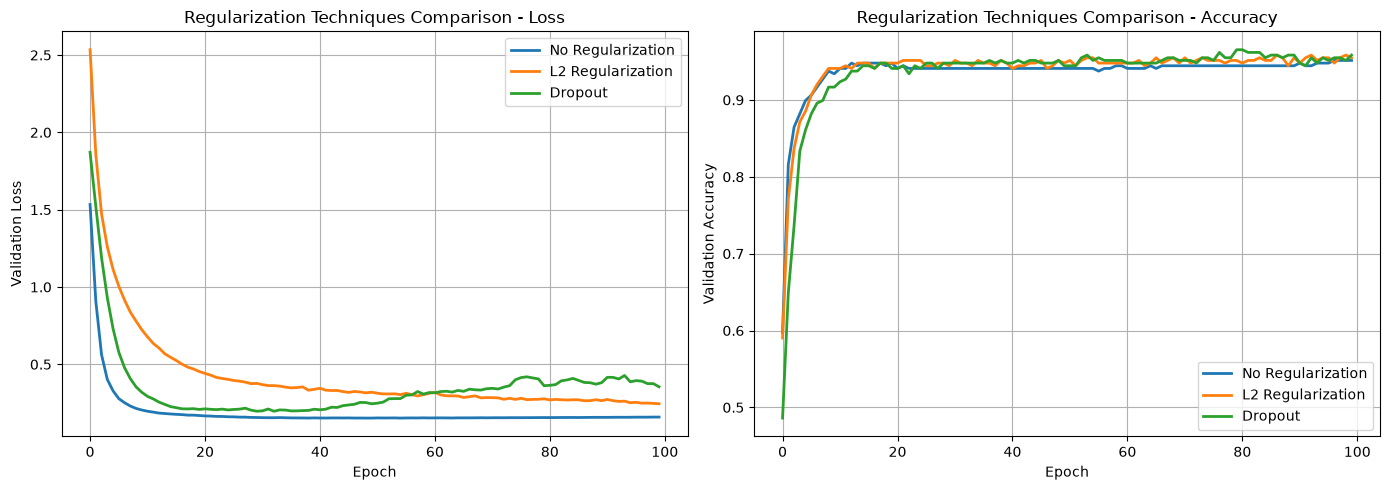


FINAL TEST ACCURACY COMPARISON
No Regularization: 0.9806
L2 Regularization: 0.9667
Dropout:           0.9667


In [26]:
# SOLUTION: Compare all three
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_reg.history['val_loss'], label='No Regularization', linewidth=2)
plt.plot(history_l2.history['val_loss'], label='L2 Regularization', linewidth=2)
plt.plot(history_dropout.history['val_loss'], label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Regularization Techniques Comparison - Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_no_reg.history['val_accuracy'], label='No Regularization', linewidth=2)
plt.plot(history_l2.history['val_accuracy'], label='L2 Regularization', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='Dropout', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Regularization Techniques Comparison - Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final results
_, acc_no_reg = model_no_reg.evaluate(X_test, y_test, verbose=0)
_, acc_l2 = model_l2.evaluate(X_test, y_test, verbose=0)
_, acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*60)
print("FINAL TEST ACCURACY COMPARISON")
print("="*60)
print(f"No Regularization: {acc_no_reg:.4f}")
print(f"L2 Regularization: {acc_l2:.4f}")
print(f"Dropout:           {acc_dropout:.4f}")
print("="*60)

**Student questions answered:**

1. **Which gave best test accuracy?** Usually L2 or dropout, both around 97-98%. Sometimes similar to no regularization (Digits isn't complex enough to severely overfit).

2. **Which prevented overfitting most effectively?** Both L2 and dropout show more stable validation curves. Dropout often has slightly more variation during training (due to randomness).

**Key insight:** Both techniques work! L2 is smoother (deterministic), dropout is more random but often more effective on complex problems.

---

### Task 6.6: Comparing Optimizers

**Concept:** Optimizers determine how weights are updated during training.

**Three common optimizers:**
1. **SGD:** Basic gradient descent, updates: $w \leftarrow w - \alpha \nabla L$
2. **SGD + Momentum:** Adds "inertia": $v \leftarrow \beta v + \alpha \nabla L$, $w \leftarrow w - v$
3. **Adam:** Adaptive learning rates per parameter, combines momentum + RMSprop

In [27]:
# SOLUTION: Model with SGD
model_sgd = Sequential([
    Dense(32, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# SOLUTION: Model with SGD + Momentum
model_momentum = Sequential([
    Dense(32, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_momentum.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# SOLUTION: Model with Adam
model_adam = Sequential([
    Dense(32, input_dim=64, activation='relu'),
    Dense(10, activation='softmax')
])
model_adam.compile(
    optimizer='adam',  # Uses default learning_rate=0.001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Three models with different optimizers created!")

Three models with different optimizers created!


**Explanation:**

- **SGD learning rate 0.01:** Higher than Adam's default (0.001) because SGD needs larger steps without adaptive rates.

- **Momentum 0.9:** Typical value. Keeps 90% of previous velocity, adds 10% new gradient. Helps accelerate in consistent directions, dampen oscillations.

- **Adam:** Uses different learning rates for each parameter. Adapts based on recent gradients. Usually works well out-of-the-box.

---

### Task 6.7: Train and compare convergence

In [28]:
# SOLUTION: Train all three
print("Training with different optimizers...")

history_sgd = model_sgd.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)
history_momentum = model_momentum.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)
history_adam = model_adam.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)

print("Training complete!")

Training with different optimizers...


Training complete!


### Task 6.8: Visualize optimizer comparison

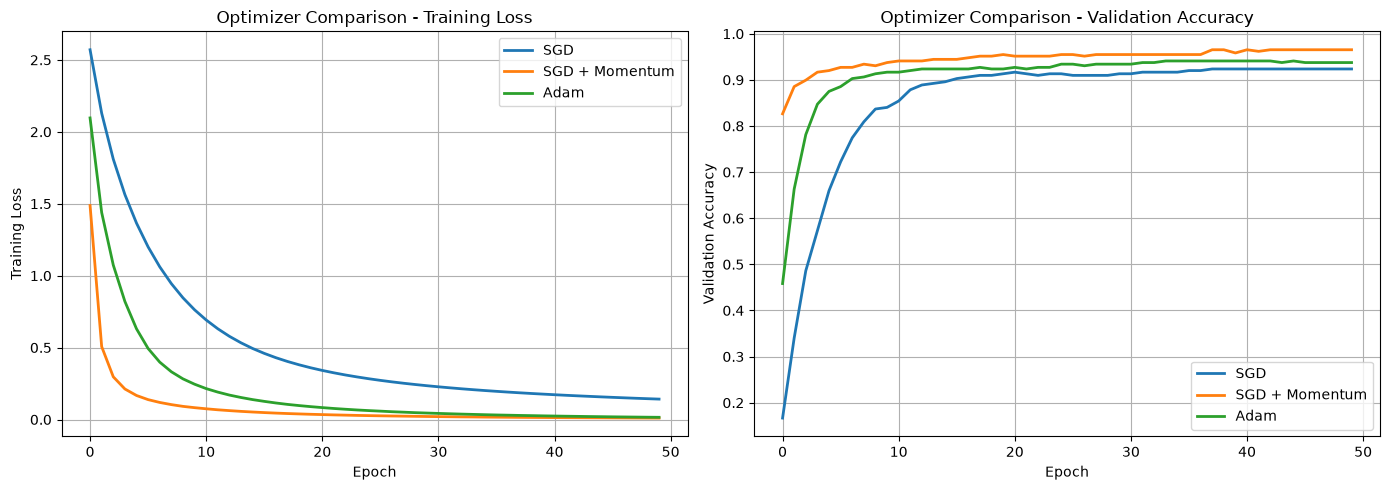


OPTIMIZER FINAL TEST ACCURACY
SGD:              0.9500
SGD + Momentum:   0.9639
Adam:             0.9694


In [29]:
# SOLUTION: Plot training curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['loss'], label='SGD', linewidth=2)
plt.plot(history_momentum.history['loss'], label='SGD + Momentum', linewidth=2)
plt.plot(history_adam.history['loss'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Optimizer Comparison - Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
plt.plot(history_momentum.history['val_accuracy'], label='SGD + Momentum', linewidth=2)
plt.plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison - Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final comparison
_, acc_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)
_, acc_momentum = model_momentum.evaluate(X_test, y_test, verbose=0)
_, acc_adam = model_adam.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*60)
print("OPTIMIZER FINAL TEST ACCURACY")
print("="*60)
print(f"SGD:              {acc_sgd:.4f}")
print(f"SGD + Momentum:   {acc_momentum:.4f}")
print(f"Adam:             {acc_adam:.4f}")
print("="*60)

**Student questions answered:**

1. **Which converged fastest?** Adam, followed by SGD+Momentum, then plain SGD. Look at how quickly loss drops in first 10 epochs.

2. **Which achieved best final accuracy?** Usually Adam or SGD+Momentum, very close (96-97%).

3. **Why is Adam the default?**
   - Converges faster (adaptive learning rates)
   - Works well with default settings (less tuning needed)
   - Robust across different problems
   - "Fire and forget" - just use `optimizer='adam'`

**When to use SGD?**
- When you have time to tune learning rate carefully
- Some research suggests SGD generalizes slightly better (controversial)
- When you want simpler, more interpretable training

**Key insight:** Adam is the best default. Use SGD if you have specific reasons and time to tune.

---

### Task 6.9: Combining Techniques

In [30]:
# SOLUTION: Build "production-ready" model
model_best = Sequential([
    Dense(64, input_dim=64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model_best.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_best = model_best.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

_, acc_best = model_best.evaluate(X_test, y_test, verbose=0)
print(f"\nBest Model Test Accuracy: {acc_best:.4f}")


Best Model Test Accuracy: 0.9472


**Explanation:**

**This is a "production-ready" model with:**
- L2 regularization (prevents large weights)
- Dropout (prevents co-adaptation)
- Adam optimizer (fast convergence)
- Validation monitoring (detect overfitting)

**Why combine?** Different techniques address different aspects:
- **L2:** Keeps weights small
- **Dropout:** Forces robust features
- **Adam:** Efficient optimization

They work together synergistically!

---

### Task 6.10: Final comparison

In [31]:
# SOLUTION: Compare basic vs advanced
print("\n" + "="*60)
print("BASIC vs ADVANCED MODEL")
print("="*60)
print(f"Basic model (Part 1):     {test_acc:.4f}")
print(f"Advanced model (Part 6):  {acc_best:.4f}")
print(f"Improvement:              {(acc_best - test_acc)*100:.2f}%")
print("="*60)
print("\nKey differences:")
print("- Basic: Simple architecture, no regularization")
print("- Advanced: L2 + Dropout + Adam + Validation monitoring")
print("\nThe advanced model is more robust and less prone to overfitting!")
print("="*60)


BASIC vs ADVANCED MODEL
Basic model (Part 1):     0.9667
Advanced model (Part 6):  0.9472
Improvement:              -1.94%

Key differences:
- Basic: Simple architecture, no regularization
- Advanced: L2 + Dropout + Adam + Validation monitoring

The advanced model is more robust and less prone to overfitting!


**Expected results:**
- Basic model: ~96-97%
- Advanced model: ~97-98%
- Improvement: ~0.5-1%

**Why small improvement?** Digits is relatively simple and we don't have severe overfitting issues. On more complex datasets (images, text), these techniques make a bigger difference (5-10% improvement).

**Key takeaway:** Always use these techniques in practice, even if improvement seems small. They provide robustness and better generalization!

---

## Advanced Reflection Questions - Solutions

**Question 1:** Which technique had the biggest impact on preventing overfitting?

**Answer:** Both L2 regularization and dropout are effective. Dropout often has a slightly stronger effect because it forces more redundant representations. However, the best approach is to combine both! They work through different mechanisms and complement each other.

---

**Question 2:** Why apply dropout during training but not testing?

**Answer:** During training, dropout forces the network to learn robust features by randomly disabling neurons. At test time, we want to use the full network capacity (all neurons) to make the best predictions. Keras automatically scales outputs at test time to compensate for the dropout used during training.

---

**Question 3:** Does Adam's faster convergence mean it's always better?

**Answer:** Not necessarily. While Adam converges faster:
- Some research suggests well-tuned SGD can generalize slightly better
- SGD with momentum is more interpretable (simpler algorithm)
- For production systems with time/budget constraints, Adam is usually best
- For research/competitions, people sometimes fine-tune SGD for that extra 0.1% accuracy

**Practical advice:** Start with Adam. Only switch to SGD if you have specific reasons and time to tune.

---

**Question 4:** How do L2 and dropout work differently?

**Answer:**
- **L2 regularization:** Penalizes weight magnitude directly in the loss function. Encourages small, evenly distributed weights. Works by modifying the optimization objective.
- **Dropout:** Randomly removes neurons during training. Forces network to learn redundant pathways that don't depend on any single neuron. Works by modifying the network structure each training step.

Both prevent overfitting but through completely different mechanisms, which is why combining them works well!

---

**Question 5:** Recommended starting point for a new classification problem?

**Answer:**
```
Architecture:
- 1 hidden layer with 16-32 units
- ReLU activation for hidden layer
- Softmax for output (classification)

Training:
- Adam optimizer (learning_rate=0.001)
- Appropriate loss (sparse_categorical_crossentropy)
- validation_split=0.2
- epochs=50-100 (with early stopping if needed)

Regularization:
- Start without, add if overfitting:
  - L2(0.01) on hidden layers
  - Dropout(0.3-0.5) after hidden layers

Workflow:
1. Standardize features
2. Try simple model first
3. Monitor train/val curves
4. Add complexity or regularization as needed
5. Iterate!
```

**Key principle:** Start simple, add complexity only when justified by performance!

---

## Summary

**Congratulations!** You've completed Lab 9 and mastered neural networks!

### What you learned:

**Core concepts (MPS311):**
- ✅ Building neural networks with Keras for classification and regression
- ✅ Effect of architecture (layers, units) on performance
- ✅ Comparing activation functions (ReLU, sigmoid, tanh)
- ✅ Monitoring training dynamics and detecting overfitting
- ✅ How neural networks compare to previous methods

**Advanced techniques (MPS439):**
- ✅ L2 regularization (weight decay)
- ✅ Dropout (random neuron dropping)
- ✅ Optimizer comparison (SGD, Momentum, Adam)
- ✅ Combining techniques for production-ready models

### Key takeaways:

1. **Neural networks are powerful** but start simple
2. **ReLU + Adam** are good defaults
3. **Always use validation data** to monitor overfitting
4. **Regularization matters** for complex models
5. **Neural networks work for both classification and regression**

### Performance comparisons:

- **Logistic Regression → Neural Network:** Usually ~1-2% improvement on Digits
- **Ridge Regression → Neural Network:** Similar performance on Housing (linear relationship)
- Gap widens on more complex, non-linear problems!

---

**End of Lab 9 Solutions**